In [1]:
# CPU allocation: set CPU_RANGE to e.g. "0-7" before running this cell.
import os
CPU_RANGE = ""
def _parse_cpu_range(spec):
    cpus = []
    for part in str(spec).split(','):
        part = part.strip()
        if not part:
            continue
        if '-' in part:
            lo, hi = part.split('-', 1)
            cpus.extend(range(int(lo), int(hi) + 1))
        else:
            cpus.append(int(part))
    return cpus
if CPU_RANGE and hasattr(os, 'sched_setaffinity'):
    os.sched_setaffinity(0, _parse_cpu_range(CPU_RANGE))
os.environ.setdefault('OMP_NUM_THREADS', str(len(_parse_cpu_range(CPU_RANGE)) or 1))
os.environ.setdefault('OPENBLAS_NUM_THREADS', os.environ['OMP_NUM_THREADS'])
os.environ.setdefault('MKL_NUM_THREADS', os.environ['OMP_NUM_THREADS'])
print('affinity =', sorted(os.sched_getaffinity(0)) if hasattr(os, 'sched_getaffinity') else 'unavailable')

affinity = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


In [2]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'cpu_cft_extraction':
    NOTEBOOK_DIR = Path('/home/abhuiyan/class_A_fermionic_adaptive_circuit/cpu_cft_extraction')
sys.path.insert(0, str(NOTEBOOK_DIR))
from cft_analysis import fit_campaign

CAMPAIGN_DIR = os.environ.get('CAMPAIGN_DIR') or None
outputs = NOTEBOOK_DIR / 'outputs'
if CAMPAIGN_DIR is None:
    campaigns = sorted([p for p in outputs.glob('*') if (p / 'scalars_by_size.csv').exists()])
    if not campaigns:
        raise FileNotFoundError('Run run_cpu_cft_sweep.py --smoke first, or set CAMPAIGN_DIR.')
    campaign = campaigns[-1]
else:
    campaign = Path(CAMPAIGN_DIR).expanduser().resolve()
with open(campaign / 'manifest.json', 'r', encoding='utf-8') as fh:
    manifest = json.load(fh)
with open(campaign / 'scalars_by_size.csv', 'r', encoding='utf-8') as fh:
    scalars = list(csv.DictReader(fh))
print(campaign)
print(json.dumps(manifest, indent=2)[:1200])

/home/abhuiyan/class_A_fermionic_adaptive_circuit/cpu_cft_extraction/outputs/tmux_cft_20260806_000032/production/20260806_001959_88d7bf97e4
{
  "Nx": 20,
  "Ny": [
    20,
    30,
    40
  ],
  "alpha": 1.0,
  "available_cpus_at_launch": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
  

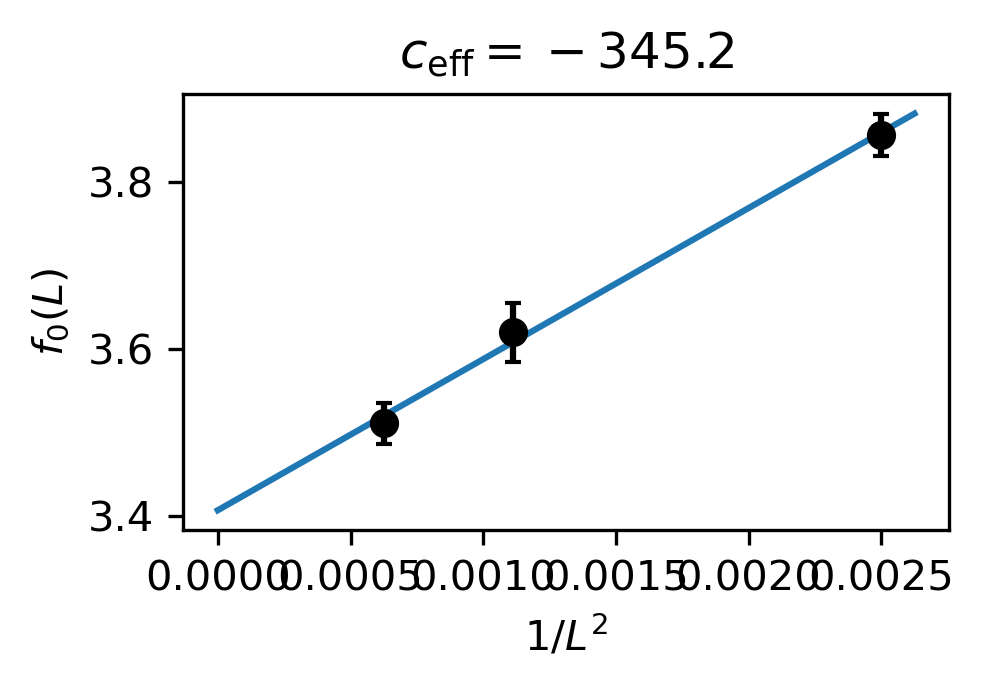

In [3]:
# Figure: f0 versus inverse circumference squared.
L = np.array([float(r['L']) for r in scalars])
f0 = np.array([float(r['f0']) for r in scalars])
f0_se = np.array([float(r['f0_se']) for r in scalars])
x = 1 / L**2
fit = fit_campaign(scalars, alpha=float(manifest['alpha']))
xx = np.linspace(0, x.max() * 1.05, 200)
yy = fit['ceff_fit']['intercept'] + fit['ceff_fit']['slope'] * xx
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.errorbar(x, f0, yerr=f0_se, fmt='o', color='black', capsize=2)
ax.plot(xx, yy, color='tab:blue')
ax.set_xlabel(r'$1/L^2$')
ax.set_ylabel(r'$f_0(L)$')
ax.set_title(rf'$c_{{\rm eff}}={fit["ceff"]:.4g}$')
fig.tight_layout()
plt.show()

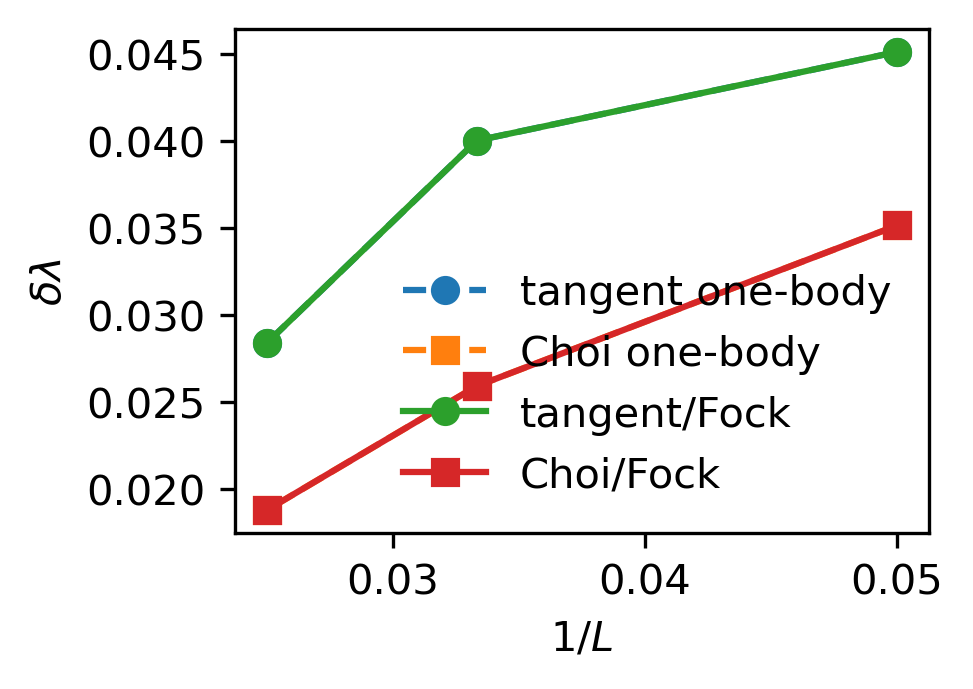

In [4]:
# Figure: one-body and additive Fock gaps versus inverse circumference.
tan_one = np.array([float(r['tangent_one_body_gap']) for r in scalars])
choi_one = np.array([float(r['choi_one_body_gap']) for r in scalars])
tan_gap = np.array([float(r['tangent_fock_gap']) for r in scalars])
choi_gap = np.array([float(r['choi_fock_gap']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(1/L, tan_one, 'o--', label=r'tangent one-body')
ax.plot(1/L, choi_one, 's--', label=r'Choi one-body')
ax.plot(1/L, tan_gap, 'o-', label=r'tangent/Fock')
ax.plot(1/L, choi_gap, 's-', label=r'Choi/Fock')
ax.set_xlabel(r'$1/L$')
ax.set_ylabel(r'$\delta\lambda$')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

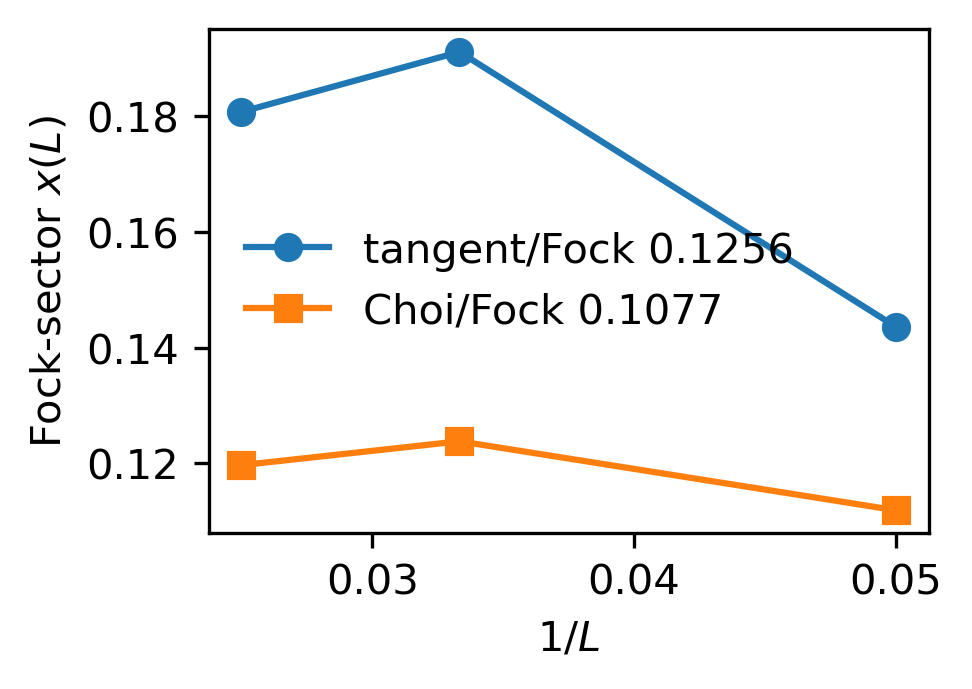

In [5]:
# Figure: size-resolved x estimates.
x_tan = np.array([float(r['x_tangent_fock_size']) for r in scalars])
x_choi = np.array([float(r['x_choi_fock_size']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(1/L, x_tan, 'o-', label=rf'tangent/Fock {fit["x_tangent_fock"]:.4g}')
ax.plot(1/L, x_choi, 's-', label=rf'Choi/Fock {fit["x_choi_fock"]:.4g}')
ax.set_xlabel(r'$1/L$')
ax.set_ylabel(r'Fock-sector $x(L)$')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

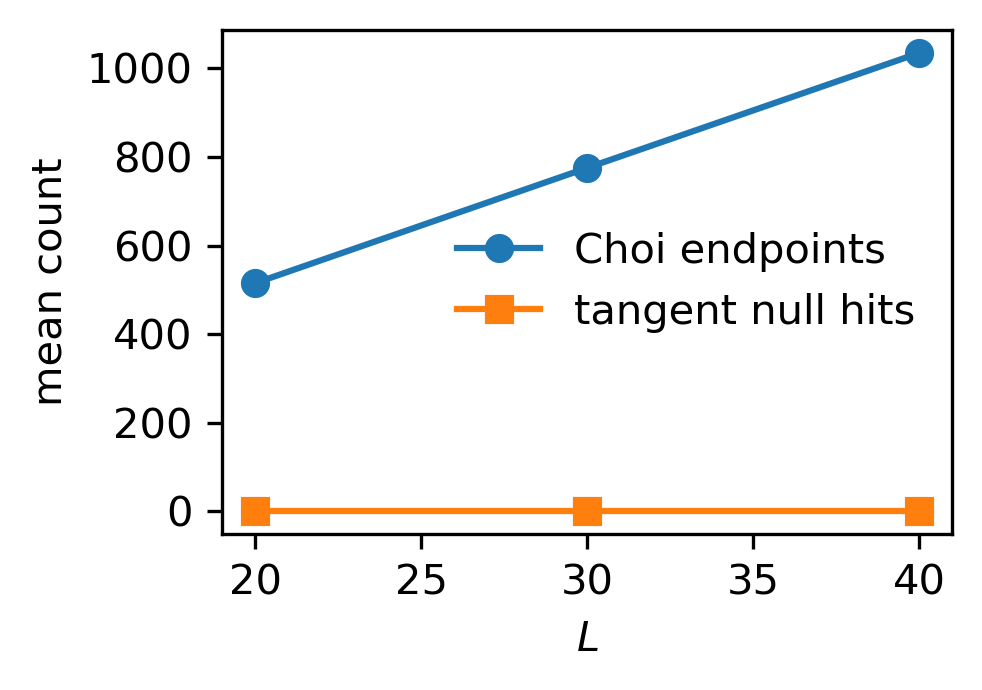

In [6]:
# Figure: endpoint and null-sector bookkeeping.
endpoint = np.array([float(r['choi_endpoint_mean']) for r in scalars])
nulls = np.array([float(r['tangent_null_mean']) for r in scalars])
fig, ax = plt.subplots(figsize=(3.375, 2.4), dpi=300)
ax.plot(L, endpoint, 'o-', label='Choi endpoints')
ax.plot(L, nulls, 's-', label='tangent null hits')
ax.set_xlabel(r'$L$')
ax.set_ylabel('mean count')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [7]:
# Summary table.
print(json.dumps(fit, indent=2))
for row in scalars:
    print(row)

{
  "ceff": -345.16629874817284,
  "ceff_fit": {
    "intercept": 3.4071035502401386,
    "slope": 180.72865140233992,
    "intercept_se": 0.018224076799632956,
    "slope_se": 11.2480066392608,
    "n": 3
  },
  "alpha": 1.0,
  "x_tangent_fock": 0.12556645676827516,
  "x_tangent_fock_fit": {
    "intercept": 0.0003190904879659539,
    "slope": 0.7889573162410272,
    "intercept_se": 0.00020709487817643308,
    "slope_se": 0.1278201683572987,
    "n": 3
  },
  "x_choi_fock": 0.1077495818601407,
  "x_choi_fock_fit": {
    "intercept": 7.455607016136411e-05,
    "slope": 0.6770105895983801,
    "intercept_se": 5.607217462447768e-05,
    "slope_se": 0.03460807367024587,
    "n": 3
  }
}
{'Nx': '20', 'Ny': '20', 'L': '20', 'cycles': '40', 'samples': '10', 'alpha': '1.0', 'valid_weight_samples': '10', 'f0': '3.855768353910767', 'f0_se': '0.0254800867798476', 'fock_rank': '1', 'tangent_one_body_gap': '0.04511220465433896', 'tangent_one_body_gap_se': '0.012866172502246078', 'tangent_fock_gap'